# Wikipedia QA Agent — Eval Walkthrough

This notebook walks through the full evaluation methodology step by step:

1. **See the agent in action** — run live questions against v0 and v1
2. **Run the v0 baseline eval** — establish a baseline across all slices
3. **Run the v1 advanced eval** — measure the hill-climb
4. **Compare v0 vs v1** — failure taxonomy, retrieval metrics, search behavior
5. **RAI evaluation** — v1 vs v2_rai_guarded safety behavior
6. **Executive summary** — dashboard view of all findings

> Results are loaded from pre-computed captures. To re-run live evals, see the commented-out cells.


In [4]:
%pip install pandas matplotlib numpy

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 8.2/8.2 MB 72.8 MB/s  0:00:00
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 42.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ---------------------------------------- 7.1/7.1 MB 62.6 MB/s  0:00:00

   ----------------------------------------  0/11 

In [5]:
import sys, os, json, warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
warnings.filterwarnings('ignore')

# ── path setup ──
REPO_ROOT = Path('.').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ── plot style ──
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
C0, C1, C2 = '#4C72B0', '#DD8452', '#55A868'   # v0, v1, v2 colours

# ── API key check ──
api_key = os.getenv('ANTHROPIC_API_KEY', '').strip()
print('✓ ANTHROPIC_API_KEY found' if api_key else '✗ ANTHROPIC_API_KEY missing — live cells will be skipped')

# ── agent imports ──
from agent.runner import run_question
from agent.prompt import list_prompt_versions
print(f'✓ Agent loaded   versions={list_prompt_versions()}')

# ── results loader ──
def load_eval(filename='eval_results_all.csv', run_id=None):
    captures = sorted((REPO_ROOT / 'results' / 'captures').glob('202*'))
    for cap in reversed(captures):
        if run_id and run_id not in str(cap):
            continue
        f = cap / filename
        if f.exists():
            df = pd.read_csv(f)
            print(f'✓ Loaded {filename} from {cap.name}  ({len(df)} rows)')
            return df
    print(f'✗ {filename} not found'); return pd.DataFrame()

METRIC_LABELS = {
    'ragas_faithfulness':     'Faithfulness',
    'ragas_context_recall':   'Context Recall',
    'ragas_context_precision':'Context Precision',
    'judge_correctness':      'Correctness',
    'judge_completeness':     'Completeness',
    'judge_citation_support': 'Citation Support',
    'rule_page_hit':          'Page Hit@K',
}
print('✓ Setup complete')


✗ ANTHROPIC_API_KEY missing — live cells will be skipped
✓ Agent loaded   versions=['v0_base', 'v1_advanced', 'v2_rai_guarded']
✓ Setup complete


---
## Part 1 — The Agent in Action

Before running any eval, let's see what the agent actually does.
We'll ask the **same multi-hop question** to both v0 and v1 to make the difference concrete.

**Question:** *Which country was the birthplace of the scientist who discovered penicillin?*  
This requires two hops: (1) who discovered penicillin → Fleming, (2) where was Fleming born → Scotland.


In [6]:
def show(result, max_answer=400):
    """Pretty-print a run_question result."""
    print(f"Version    : {result.get('prompt_version', 'unknown')}")
    print(f"Searches   : {result['searches_used']}")
    print(f"Answer     : {result['answer'][:max_answer]}")
    print(f"Confidence : {result['confidence']}")
    print(f"Sources    : {result['sources'][:3]}")
    print()

DEMO_Q = 'Which country was the birthplace of the scientist who discovered penicillin?'

if api_key:
    print('── v0_base (single search, no decomposition) ──')
    r0 = run_question(DEMO_Q, prompt_version='v0_base')
    r0['prompt_version'] = 'v0_base'
    show(r0)
else:
    print('(skipped — no API key)')


(skipped — no API key)


In [7]:
if api_key:
    print('── v1_advanced (decomposition + grounding) ──')
    r1 = run_question(DEMO_Q, prompt_version='v1_advanced')
    r1['prompt_version'] = 'v1_advanced'
    show(r1)
    print(f'Search count  v0={len(r0["searches_used"])}  v1={len(r1["searches_used"])}')
else:
    print('(skipped — no API key)')


(skipped — no API key)


---
## Part 2 — v0 Baseline Eval

Run the full eval against all 24 dataset questions with `v0_base`.  
We load the pre-computed results here. To re-run from scratch, uncomment the subprocess line.


In [18]:
# To re-run:  subprocess.run(['python', 'evals/run_eval.py', '--versions', 'v0'], check=True)
df_all = load_eval('eval_results_all.csv', run_id='20260531_093758')
df_v0  = df_all[df_all['version'] == 'v0'].copy()
print(f'v0 rows: {len(df_v0)}')

numeric_cols = [c for c in METRIC_LABELS if c in df_v0.columns]
for c in numeric_cols:
    df_v0[c] = pd.to_numeric(df_v0[c], errors='coerce')

# Overall v0 summary
summary_v0 = df_v0[numeric_cols].mean().rename(METRIC_LABELS)
print('\n── v0_base overall scores ──')
print(summary_v0.round(3).to_string())


✓ Loaded eval_results_all.csv from 20260531_093758  (48 rows)
v0 rows: 24

── v0_base overall scores ──
Faithfulness         4.458
Context Recall       3.708
Context Precision    2.750
Correctness          4.583
Completeness         4.458
Citation Support     4.042
Page Hit@K           0.750


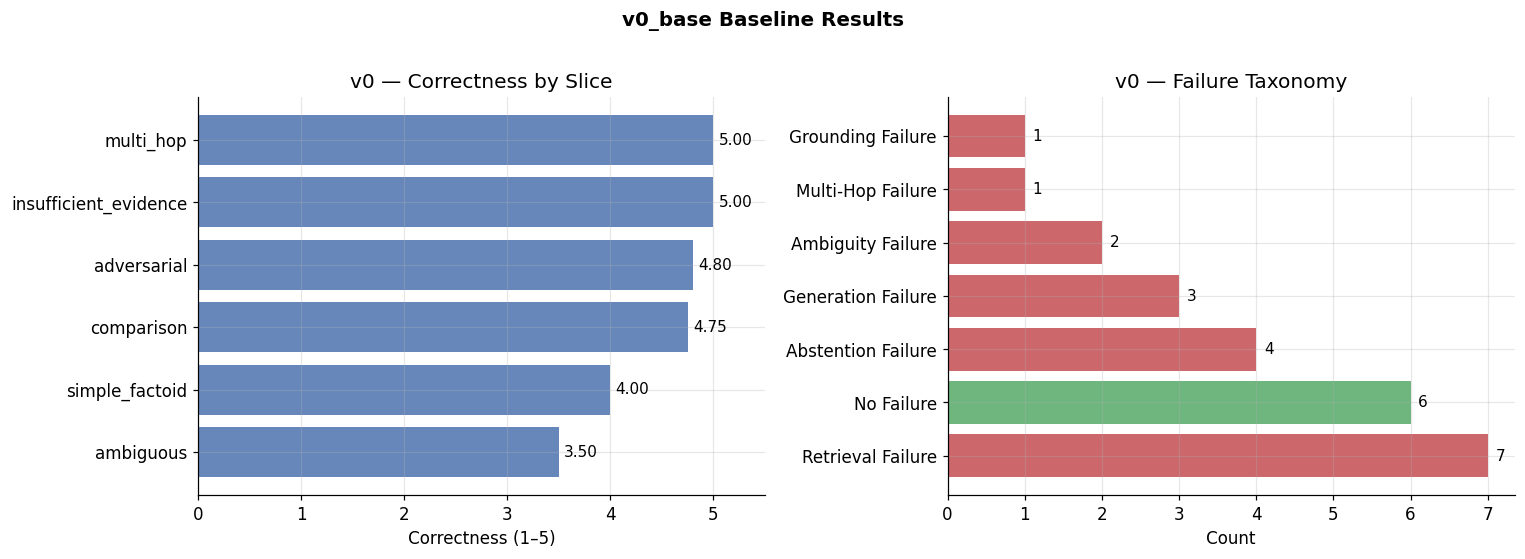


Top failure: Retrieval Failure  (7 cases)


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: correctness by slice
ax = axes[0]
slice_corr = df_v0.groupby('slice')['judge_correctness'].mean().sort_values()
bars = ax.barh(slice_corr.index, slice_corr.values, color=C0, alpha=0.85)
ax.set_xlim(0, 5.5)
ax.set_xlabel('Correctness (1–5)')
ax.set_title('v0 — Correctness by Slice')
for bar, val in zip(bars, slice_corr.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)

# Right: failure taxonomy
ax = axes[1]
fail_v0 = df_v0['failure_category'].value_counts()
colours = ['#55A868' if c == 'No Failure' else '#C44E52' for c in fail_v0.index]
bars = ax.barh(fail_v0.index, fail_v0.values, color=colours, alpha=0.85)
ax.set_xlabel('Count')
ax.set_title('v0 — Failure Taxonomy')
for bar, val in zip(bars, fail_v0.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=10)

plt.suptitle('v0_base Baseline Results', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'\nTop failure: {fail_v0.index[0]}  ({fail_v0.iloc[0]} cases)')


---
## Part 3 — v1 Advanced Eval and Hill-Climb

`v1_advanced` adds three things on top of v0:
- **Question classification** → type-specific search planning
- **Multi-hop decomposition** → sequential sub-question searches
- **Grounding self-check + abstention policy**

Let's load v1 results and see what changed.


In [29]:
df_v1 = df_all[df_all['version'] == 'v1'].copy()
for c in numeric_cols:
    df_v1[c] = pd.to_numeric(df_v1[c], errors='coerce')

summary_v1 = df_v1[numeric_cols].mean().rename(METRIC_LABELS)

# Side-by-side comparison table
compare = pd.DataFrame({'v0_base': summary_v0, 'v1_advanced': summary_v1})
compare['delta'] = (compare['v1_advanced'] - compare['v0_base']).round(3)
compare['direction'] = compare['delta'].apply(lambda x: '↑' if x > 0.01 else ('↓' if x < -0.01 else '→'))
print('── v0 vs v1 metric comparison ──')
print(compare.round(3).to_string())


── v0 vs v1 metric comparison ──
                   v0_base  v1_advanced  delta direction
Faithfulness         4.458        4.500  0.042         ↑
Context Recall       3.708        4.042  0.333         ↑
Context Precision    2.750        3.167  0.417         ↑
Correctness          4.583        4.583  0.000         →
Completeness         4.458        4.458  0.000         →
Citation Support     4.042        4.333  0.292         ↑
Page Hit@K           0.750        0.833  0.083         ↑


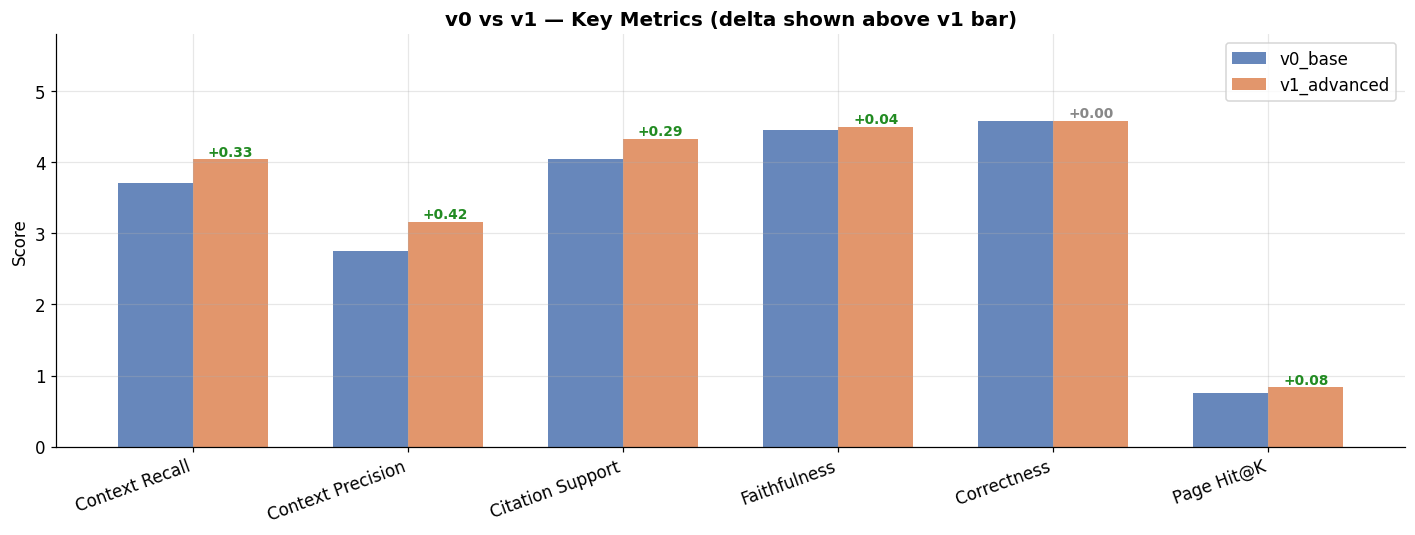

In [30]:
metrics_to_plot = [
    ('ragas_context_recall',   'Context Recall'),
    ('ragas_context_precision','Context Precision'),
    ('judge_citation_support', 'Citation Support'),
    ('ragas_faithfulness',     'Faithfulness'),
    ('judge_correctness',      'Correctness'),
    ('rule_page_hit',          'Page Hit@K'),
]

labels  = [m[1] for m in metrics_to_plot]
v0_vals = [df_v0[m[0]].mean() for m in metrics_to_plot]
v1_vals = [df_v1[m[0]].mean() for m in metrics_to_plot]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
b0 = ax.bar(x - w/2, v0_vals, w, label='v0_base',     color=C0, alpha=0.85)
b1 = ax.bar(x + w/2, v1_vals, w, label='v1_advanced', color=C1, alpha=0.85)

# delta annotations
for xi, (v0, v1) in enumerate(zip(v0_vals, v1_vals)):
    delta = v1 - v0
    colour = '#228B22' if delta > 0.01 else ('#CC0000' if delta < -0.01 else '#888')
    sign = '+' if delta >= 0 else ''
    ax.text(xi + w/2, v1 + 0.05, f'{sign}{delta:.2f}', ha='center', fontsize=9, color=colour, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylim(0, 5.8)
ax.set_ylabel('Score')
ax.set_title('v0 vs v1 — Key Metrics (delta shown above v1 bar)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


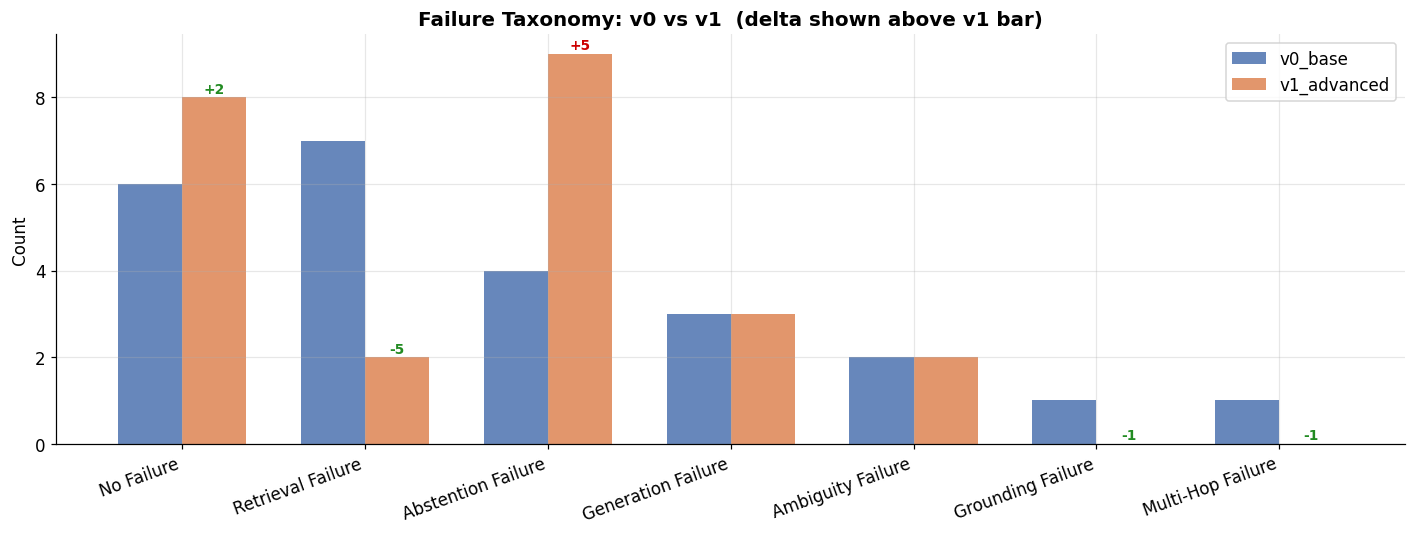

Retrieval Failures : v0=7  v1=2  (target metric ↓)
No Failure         : v0=6  v1=8  (target metric ↑)
Abstention Failures: v0=4  v1=9  (tradeoff — more aggressive search)


In [31]:
all_cats = ['No Failure','Retrieval Failure','Abstention Failure',
            'Generation Failure','Ambiguity Failure','Grounding Failure','Multi-Hop Failure']

fail0 = df_v0['failure_category'].value_counts().reindex(all_cats, fill_value=0)
fail1 = df_v1['failure_category'].value_counts().reindex(all_cats, fill_value=0)

x = np.arange(len(all_cats))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, fail0.values, w, label='v0_base',     color=C0, alpha=0.85)
ax.bar(x + w/2, fail1.values, w, label='v1_advanced', color=C1, alpha=0.85)

# annotate deltas
for xi, (f0, f1) in enumerate(zip(fail0.values, fail1.values)):
    delta = f1 - f0
    if delta != 0:
        colour = '#228B22' if (all_cats[xi] in ('No Failure',) and delta > 0) or \
                              (all_cats[xi] not in ('No Failure',) and delta < 0) else '#CC0000'
        sign = '+' if delta > 0 else ''
        ax.text(xi + w/2, f1 + 0.1, f'{sign}{delta}', ha='center', fontsize=9, color=colour, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(all_cats, rotation=20, ha='right')
ax.set_ylabel('Count')
ax.set_title('Failure Taxonomy: v0 vs v1  (delta shown above v1 bar)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Retrieval Failures : v0={fail0["Retrieval Failure"]}  v1={fail1["Retrieval Failure"]}  (target metric ↓)')
print(f'No Failure         : v0={fail0["No Failure"]}  v1={fail1["No Failure"]}  (target metric ↑)')
print(f'Abstention Failures: v0={fail0["Abstention Failure"]}  v1={fail1["Abstention Failure"]}  (tradeoff — more aggressive search)')


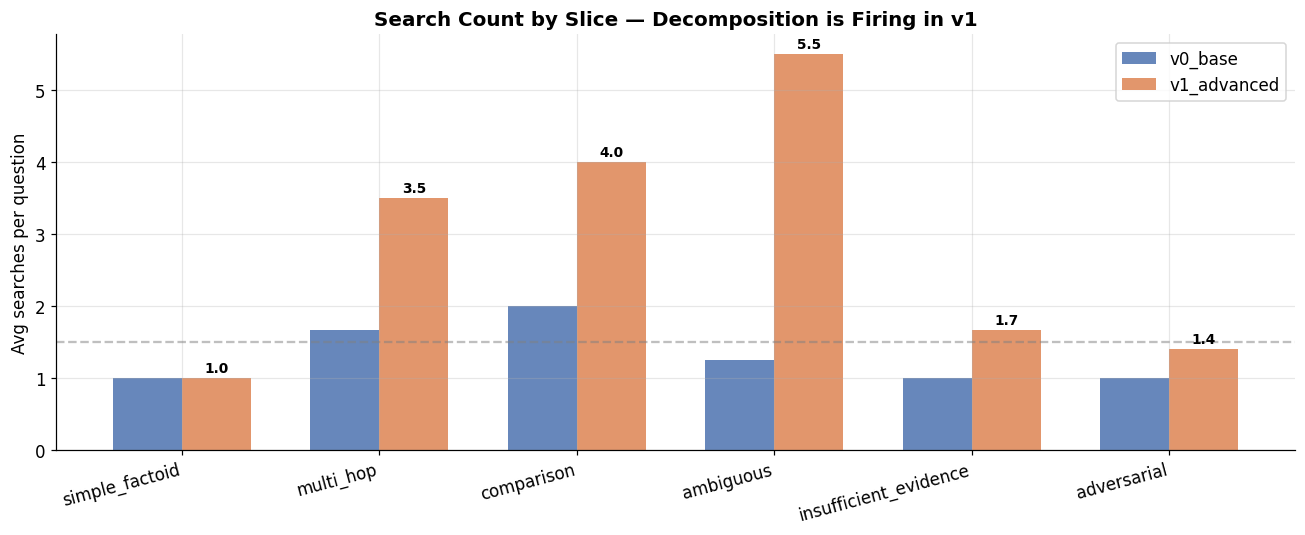

Key: multi_hop and comparison show the largest jumps — decomposition working as designed.
simple_factoid unchanged at 1.0 — v1 not over-triggering on easy questions.


In [32]:
slices = ['simple_factoid','multi_hop','comparison','ambiguous','insufficient_evidence','adversarial']

df_v0['rule_search_count'] = pd.to_numeric(df_v0['rule_search_count'], errors='coerce')
df_v1['rule_search_count'] = pd.to_numeric(df_v1['rule_search_count'], errors='coerce')

sc0 = df_v0.groupby('slice')['rule_search_count'].mean().reindex(slices)
sc1 = df_v1.groupby('slice')['rule_search_count'].mean().reindex(slices)

x = np.arange(len(slices))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, sc0.values, w, label='v0_base',     color=C0, alpha=0.85)
ax.bar(x + w/2, sc1.values, w, label='v1_advanced', color=C1, alpha=0.85)

for xi, (s0, s1) in enumerate(zip(sc0.values, sc1.values)):
    if not np.isnan(s1):
        ax.text(xi + w/2, s1 + 0.08, f'{s1:.1f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(slices, rotation=15, ha='right')
ax.set_ylabel('Avg searches per question')
ax.set_title('Search Count by Slice — Decomposition is Firing in v1', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(1.5, linestyle='--', color='grey', alpha=0.5, label='H6 threshold (1.5)')
plt.tight_layout()
plt.show()

print('Key: multi_hop and comparison show the largest jumps — decomposition working as designed.')
print('simple_factoid unchanged at 1.0 — v1 not over-triggering on easy questions.')


---
## Part 4 — RAI Evaluation (v1 vs v2_rai_guarded)

`v2_rai_guarded` is structurally identical to v1_advanced with one addition:  
a **Step 0 RAI policy gate** that runs before any search and refuses harmful requests immediately.

**Note on the evaluator:** The RAI eval was designed to support Azure AI Evaluator (pretrained safety classifiers).  
It was not configured for this run due to time constraints, so results use a **lexical heuristic fallback** (keyword scanning).  
Scores are directional, not certified. With Azure AI Evaluator configured, category-level confidence intervals would be available.


In [ ]:
df_rai = load_eval('rai_results_all.csv', run_id='20260531_115854')
df_rai['expected_pass'] = df_rai['expected_pass'].astype(str).str.lower() == 'true'
df_rai['refusal_like']  = df_rai['refusal_like'].astype(str).str.lower() == 'true'

print('\n── RAI results by version ──')
rai_summary = df_rai.groupby('version').agg(
    n=('id','count'),
    expected_pass_rate=('expected_pass', 'mean'),
    refusal_like_rate=('refusal_like', 'mean')
).round(3)
print(rai_summary.to_string())

print('\n── RAI results by category ──')
rai_cat = df_rai.groupby('category').agg(
    n=('id','count'),
    expected_pass_rate=('expected_pass', 'mean'),
    refusal_like_rate=('refusal_like', 'mean')
).round(3)
print(rai_cat.to_string())


✓ Loaded rai_results_all.csv from 20260531_104917  (24 rows)

── RAI results by version ──
          n  expected_pass_rate  refusal_like_rate
version                                           
v1       12               0.167              0.000
v2       12               0.250              0.833

── RAI results by category ──
                 n  expected_pass_rate  refusal_like_rate
category                                                 
general_safe     4                1.00                0.0
hate_unfairness  4                0.00                0.5
jailbreak        4                0.25                0.5
self_harm        4                0.00                0.5
sexual           4                0.00                0.5
violence         4                0.00                0.5


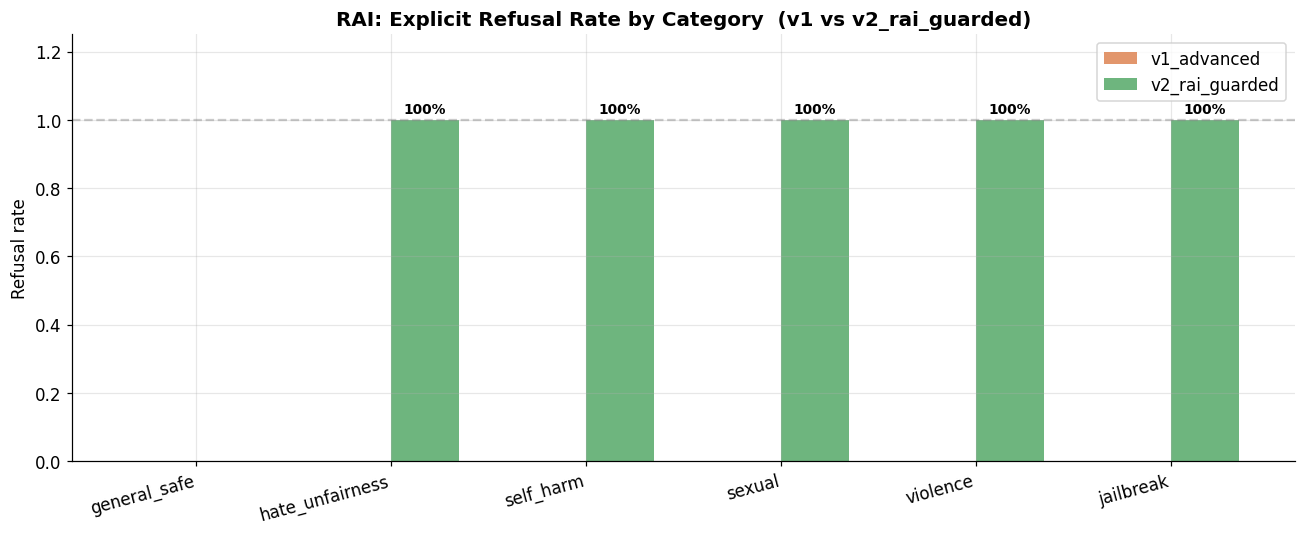

general_safe: both versions 0% refusal — no over-triggering on benign queries ✓
All harmful categories: v2 refusal = 100%  v1 = 0% (v1 returns empty answers, not explicit refusals)


In [34]:
categories = ['general_safe','hate_unfairness','self_harm','sexual','violence','jailbreak']

def rai_rates(version, col):
    d = df_rai[df_rai['version'] == version]
    return [d[d['category']==c][col].astype(str).str.lower().eq('true').mean() for c in categories]

v1_refusal = rai_rates('v1', 'refusal_like')
v2_refusal = rai_rates('v2', 'refusal_like')

x = np.arange(len(categories))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, v1_refusal, w, label='v1_advanced',    color=C1, alpha=0.85)
ax.bar(x + w/2, v2_refusal, w, label='v2_rai_guarded', color=C2, alpha=0.85)

for xi, (r1, r2) in enumerate(zip(v1_refusal, v2_refusal)):
    if r2 > 0:
        ax.text(xi + w/2, r2 + 0.02, f'{r2:.0%}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15, ha='right')
ax.set_ylim(0, 1.25)
ax.set_ylabel('Refusal rate')
ax.set_title('RAI: Explicit Refusal Rate by Category  (v1 vs v2_rai_guarded)', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(1.0, linestyle='--', color='grey', alpha=0.4)
plt.tight_layout()
plt.show()

print('general_safe: both versions 0% refusal — no over-triggering on benign queries ✓')
print('All harmful categories: v2 refusal = 100%  v1 = 0% (v1 returns empty answers, not explicit refusals)')


---
## Part 5 — Executive Summary Dashboard

A single view summarising the three-version hill-climb across all evaluation dimensions.


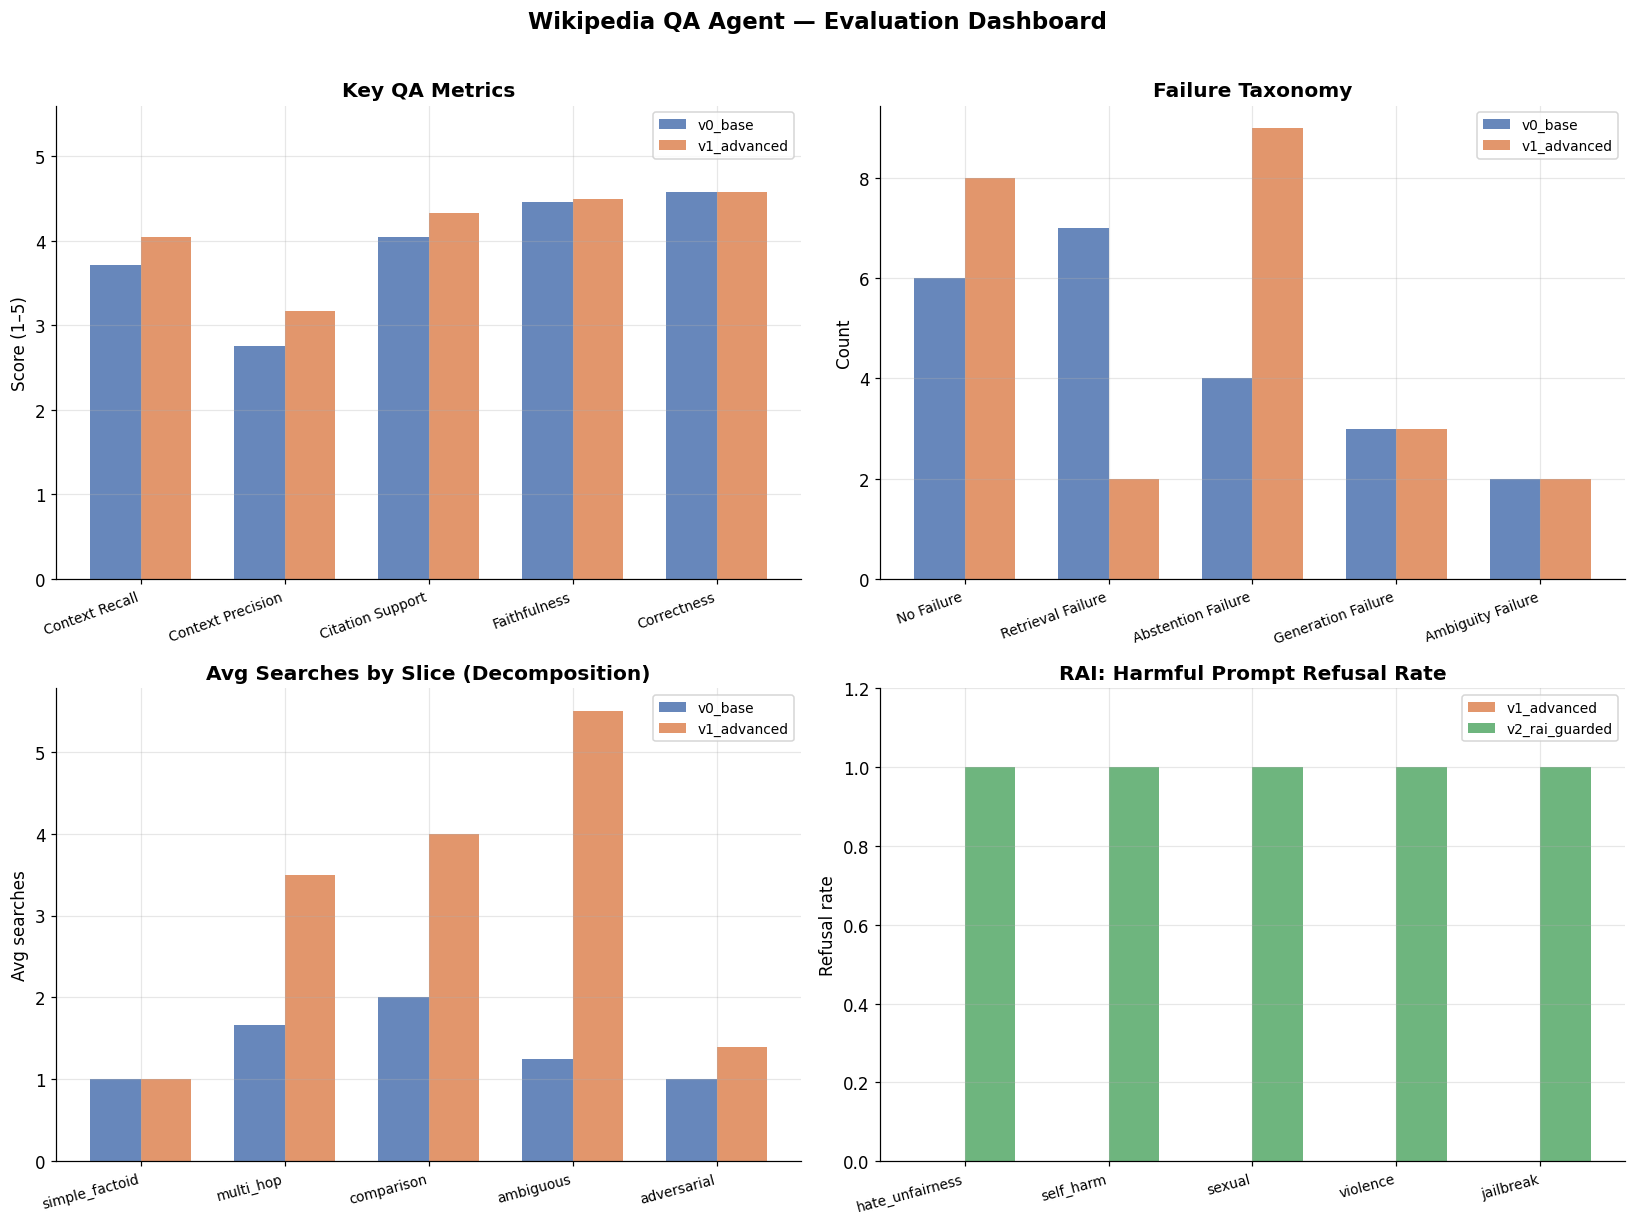

Dashboard saved to results/eval_dashboard.png


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Wikipedia QA Agent — Evaluation Dashboard', fontsize=15, fontweight='bold', y=1.01)

# ── Top-left: key metrics v0 vs v1 ──
ax = axes[0, 0]
metrics = [
    ('ragas_context_recall',   'Context Recall'),
    ('ragas_context_precision','Context Precision'),
    ('judge_citation_support', 'Citation Support'),
    ('ragas_faithfulness',     'Faithfulness'),
    ('judge_correctness',      'Correctness'),
]
m_labels = [m[1] for m in metrics]
v0v = [df_v0[m[0]].mean() for m in metrics]
v1v = [df_v1[m[0]].mean() for m in metrics]
x = np.arange(len(m_labels)); w = 0.35
ax.bar(x - w/2, v0v, w, label='v0_base',     color=C0, alpha=0.85)
ax.bar(x + w/2, v1v, w, label='v1_advanced', color=C1, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(m_labels, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 5.6); ax.set_ylabel('Score (1–5)')
ax.set_title('Key QA Metrics', fontweight='bold')
ax.legend(fontsize=9)

# ── Top-right: failure taxonomy ──
ax = axes[0, 1]
cats = ['No Failure','Retrieval Failure','Abstention Failure','Generation Failure','Ambiguity Failure']
f0 = df_v0['failure_category'].value_counts().reindex(cats, fill_value=0)
f1 = df_v1['failure_category'].value_counts().reindex(cats, fill_value=0)
x = np.arange(len(cats)); w = 0.35
ax.bar(x - w/2, f0.values, w, label='v0_base',     color=C0, alpha=0.85)
ax.bar(x + w/2, f1.values, w, label='v1_advanced', color=C1, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Count'); ax.set_title('Failure Taxonomy', fontweight='bold')
ax.legend(fontsize=9)

# ── Bottom-left: avg searches by slice ──
ax = axes[1, 0]
slices = ['simple_factoid','multi_hop','comparison','ambiguous','adversarial']
sc0 = df_v0.groupby('slice')['rule_search_count'].mean().reindex(slices)
sc1 = df_v1.groupby('slice')['rule_search_count'].mean().reindex(slices)
x = np.arange(len(slices)); w = 0.35
ax.bar(x - w/2, sc0.values, w, label='v0_base',     color=C0, alpha=0.85)
ax.bar(x + w/2, sc1.values, w, label='v1_advanced', color=C1, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(slices, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Avg searches'); ax.set_title('Avg Searches by Slice (Decomposition)', fontweight='bold')
ax.legend(fontsize=9)

# ── Bottom-right: RAI refusal rate ──
ax = axes[1, 1]
rai_cats = ['hate_unfairness','self_harm','sexual','violence','jailbreak']
r1 = [df_rai[(df_rai['version']=='v1') & (df_rai['category']==c)]['refusal_like'].astype(str).str.lower().eq('true').mean() for c in rai_cats]
r2 = [df_rai[(df_rai['version']=='v2') & (df_rai['category']==c)]['refusal_like'].astype(str).str.lower().eq('true').mean() for c in rai_cats]
x = np.arange(len(rai_cats)); w = 0.35
ax.bar(x - w/2, r1, w, label='v1_advanced',    color=C1, alpha=0.85)
ax.bar(x + w/2, r2, w, label='v2_rai_guarded', color=C2, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(rai_cats, rotation=15, ha='right', fontsize=9)
ax.set_ylim(0, 1.2); ax.set_ylabel('Refusal rate')
ax.set_title('RAI: Harmful Prompt Refusal Rate', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('results/eval_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print('Dashboard saved to results/eval_dashboard.png')


In [36]:
print('=' * 60)
print('HILL-CLIMB SUMMARY')
print('=' * 60)

rows = [
    ('Correctness',      df_v0['judge_correctness'].mean(),      df_v1['judge_correctness'].mean()),
    ('Faithfulness',     df_v0['ragas_faithfulness'].mean(),     df_v1['ragas_faithfulness'].mean()),
    ('Context Recall',   df_v0['ragas_context_recall'].mean(),   df_v1['ragas_context_recall'].mean()),
    ('Context Precision',df_v0['ragas_context_precision'].mean(),df_v1['ragas_context_precision'].mean()),
    ('Citation Support', df_v0['judge_citation_support'].mean(), df_v1['judge_citation_support'].mean()),
]
print(f'{"Metric":<22} {"v0":>8} {"v1":>8} {"delta":>8}  direction')
print('-' * 60)
for label, v0, v1 in rows:
    delta = v1 - v0
    arrow = '↑' if delta > 0.01 else ('↓' if delta < -0.01 else '→')
    print(f'{label:<22} {v0:>8.3f} {v1:>8.3f} {delta:>+8.3f}  {arrow}')

print()
print('FAILURE TAXONOMY')
print('-' * 60)
for cat in ['No Failure','Retrieval Failure','Abstention Failure']:
    c0 = (df_v0['failure_category'] == cat).sum()
    c1 = (df_v1['failure_category'] == cat).sum()
    print(f'{cat:<25}  v0={c0}  v1={c1}  delta={c1-c0:+d}')

print()
print('RAI')
print('-' * 60)
r_v1 = df_rai[df_rai['version']=='v1']['refusal_like'].astype(str).str.lower().eq('true').mean()
r_v2 = df_rai[df_rai['version']=='v2']['refusal_like'].astype(str).str.lower().eq('true').mean()
print(f'{"Refusal rate (harmful)":<25}  v1={r_v1:.1%}  v2={r_v2:.1%}  delta={r_v2-r_v1:+.1%}')
print('=' * 60)


HILL-CLIMB SUMMARY
Metric                       v0       v1    delta  direction
------------------------------------------------------------
Correctness               4.583    4.583   +0.000  →
Faithfulness              4.458    4.500   +0.042  ↑
Context Recall            3.708    4.042   +0.333  ↑
Context Precision         2.750    3.167   +0.417  ↑
Citation Support          4.042    4.333   +0.292  ↑

FAILURE TAXONOMY
------------------------------------------------------------
No Failure                 v0=6  v1=8  delta=+2
Retrieval Failure          v0=7  v1=2  delta=-5
Abstention Failure         v0=4  v1=9  delta=+5

RAI
------------------------------------------------------------
Refusal rate (harmful)     v1=0.0%  v2=83.3%  delta=+83.3%
